In [34]:
%matplotlib ipympl

import mujoco

import time
import itertools
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import enum
from tqdm import tqdm

import os
os.environ['MUJOCO_GL'] = 'osmesa'  # Принудительно используем EGL
os.environ['__NV_PRIME_RENDER_OFFLOAD'] = '1'
os.environ['__GLX_VENDOR_LIBRARY_NAME'] = 'nvidia'

In [35]:
class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

In [36]:
# from robot_descriptions import spot_mj_description
model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm_vel.xml")
model_xml = model_dir / "scene_arm_vel.xml"
# model = mujoco.MjModel.from_xml_path(spot_mj_description.MJCF_PATH)

# from robot_descriptions.loaders.mujoco import load_robot_description
# model = load_robot_description("spot_mj_description")

model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

""

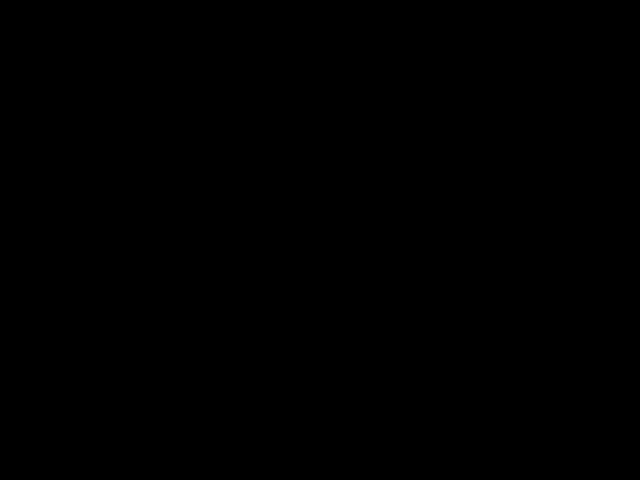

In [37]:
with mujoco.Renderer(model, h, w) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

""

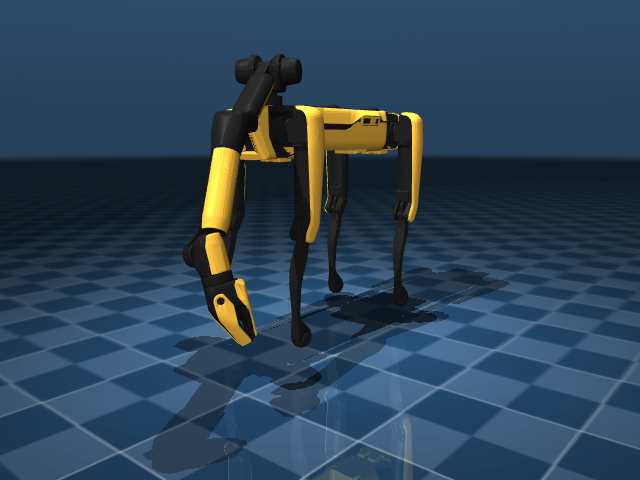

In [38]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
for joint in joints:
    data.joint(joint).qpos = np.pi/6

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
# camera.azimuth = -90
# camera.elevation = 0
camera.distance = 2

renderer = mujoco.Renderer(model, height=h, width=w)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

In [39]:
# print(data.joint('arm_sh0'))

joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3)) 
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.292 0.    0.938]
[0.292 0.    0.938]
[0.546 0.147 0.769]
[0.777 0.28  0.457]
[0.777 0.28  0.457]
[0.777 0.28  0.457]


[0.524]
[0.524]
[0.524]
[0.524]
[0.524]
[0.524]


In [40]:
from dataclasses import dataclass
import numpy as np
import mediapy as media
from pathlib import Path
import enum
from tqdm import tqdm
import mujoco

from numpy import pi

def quartic(t: float) -> float:
  return 0 if abs(t) > 1 else (1 - t**2) ** 2


def blend_coef(t: float, duration: float, std: float) -> float:
  normalised_time = 2 * t / duration - 1
  return quartic(normalised_time / std)


In [41]:
res = Resolution.SD
fps = 30
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.05

# Rendering options for visual and collision geoms.
vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

camera.distance = 2

data.joint("arm_sh0").qpos = pi/4
# data.ctrl[model.actuator("arm_sh0").id] = data.joint("arm_sh0").qpos
frames = []
for i in tqdm(range(nsteps)):
  data.joint("arm_sh0").qpos = 1
  # data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 2500/2500 [00:00<00:00, 3423.06it/s]


This browser does not support the video tag.


Важно учитывать конфигурацию робота, в которой он находится в момент расчета координат (по результатам симуляции выше) или _(как-то)_ "сбросить" положение звеньев.

In [42]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.278 0.001 0.618]
[0.278 0.001 0.618]
[ 0.095 -0.284  0.619]
[0.311 0.051 0.716]
[0.311 0.051 0.716]
[0.311 0.051 0.716]


[0.998]
[-3.14]
[3.083]
[0.]
[0.003]
[-0.]


Да, длины звеньев в целом соответствуют значениям, приведенным производителем.

In [43]:
bodies = np.array(['arm_link_sh0',
                   'arm_link_sh1', 'arm_link_el0', 'arm_link_el1', 'arm_link_wr0', 'arm_link_wr1', 'arm_link_fngr'])

def calc_vel(x, y, z):
    if len(z) < 2:
        vel = np.array([0, 0, 0])
    else:
        vel = np.array([x[-1] - x[-2],
                        y[-1] - y[-2],
                        z[-1] - z[-2]])
    return vel

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    def add_theta(self, q):
        self.theta += q
    def T_matrix(self, i):
        return np.array([
            [np.cos(self.theta[i]), -np.sin(self.theta[i])*np.cos(self.alpha[i]),   np.sin(self.theta[i])*np.sin(self.alpha[i]),    self.a[i]*np.cos(self.theta[i])],
            [np.sin(self.theta[i]), np.cos(self.theta[i])*np.cos(self.alpha[i]),    -np.cos(self.theta[i])*np.sin(self.alpha[i]),   self.a[i]*np.sin(self.theta[i])],
            [0,                     np.sin(self.alpha[i]),                          np.cos(self.alpha[i]),                          self.d[i]],
            [0,                     0,                                              0,                                              1]
            ])
       

l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117

DH = DH_params()
DH.alpha = np.array([   -pi/2,  0,      pi/2,   pi/2,   -pi/2,   pi/2])
DH.a = np.array([       0,      l2,     h3,     0,      0,      0])
DH.d = np.array([       l1,     0,      0,      l3,     0,      l5])
DH.theta = np.array([   0.0,    pi,    -pi/2,   pi,     0.0,    0.0])

# DH.add_theta(np.array([0, -pi, pi, 0, 0, 0]))

def calc_Jacobian(DH_params, p_endeff):
    J = np.zeros((6, 6))
    T = np.eye(4)
    for i in range(6):
        z_i = T[0:3, 2]
        p_i = T[0:3, 3]
        J[0:3, i] = np.cross(z_i, (p_endeff - p_i))
        J[3:6, i] = z_i
        A = DH_params.T_matrix(i)
        T = T @ A
    return J

def normalize_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

In [44]:
plt.close()

camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.azimuth = -135
camera.elevation = -45
camera.distance = 2

duration = 5.0
ctrl_rate = 2
ctrl_std = 0.075

np.random.seed(100)

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

t = np.array([])
x, y, z = np.array([]), np.array([]), np.array([])
xe, ye, ze = np.array([]), np.array([]), np.array([])
xvel, yvel, zvel = np.array([]), np.array([]), np.array([])
q0, q1, q2, q3, q4, q5 = np.array([]), np.array([]), np.array([]), np.array([]), np.array([]), np.array([])
MAX_JOINT_VEL = 1.0

frames = []

sensor_names = [
    "arm_sh0_pos", "arm_sh1_pos", "arm_el0_pos", "arm_el1_pos",
    "arm_wr0_pos", "arm_wr1_pos"
]
sensor_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, name) for name in sensor_names]

joints_vel = ["arm_sh0_vel", "arm_sh1_vel", "arm_el0_vel", "arm_el1_vel", "arm_wr0_vel", "arm_wr1_vel"]
data.joint("arm_sh0").qpos = 0.0
data.joint("arm_sh1").qpos = -3*pi/4
data.joint("arm_el0").qpos = 3*pi/4
# for joint_name in joints:
#     data.ctrl[model.actuator(joint_name).id] = data.joint(joint_name).qpos

p_base_last = data.body("arm_link_sh0").xpos.copy()
p_b_last = np.array([p_base_last[0], p_base_last[1], p_base_last[2]])
p_endeff_last = data.body("arm_link_fngr").xpos - p_base_last
p_e_last = np.array([p_endeff_last[0], p_endeff_last[1], p_endeff_last[2]])
p_e_desired = np.array([0, 0, 0])
kp = 0.1
v_corr = np.zeros(3)
v_comp = np.zeros(3)


p_desired = data.body("arm_link_fngr").xpos - data.body("arm_link_sh0").xpos

for i in tqdm(range(nsteps)):
  dt = model.opt.timestep
  t = np.append(t, i*dt)
  
  data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  
  # if i % 10 == 0:
  p_base = data.body("arm_link_sh0").xpos.copy()
  p_endeff = data.body("arm_link_fngr").xpos.copy() - p_base
  p_b = np.array([p_base[0], p_base[1], p_base[2]], dtype=np.float64)
  p_e = np.array([p_endeff[0], p_endeff[1], p_endeff[2]], dtype=np.float64)
  
  b_linvel = data.body("arm_link_sh0").cvel[:3]  # Линейная скорость
  b_angvel = data.body("arm_link_sh0").cvel[3:]  # Угловая скорость
  e_angvel = data.body("arm_link_fngr").cvel[3:]
  base_linvel = np.array([b_linvel[0], b_linvel[1], b_linvel[2]])
  base_angvel = np.array([b_angvel[0], b_angvel[1], b_angvel[2]])
  endeff_angvel = np.array([e_angvel[0], e_angvel[1], e_angvel[2]])
  r = p_endeff  
  # Эффект угловой скорости (v = ω × r)
  ang_comp = np.cross(base_angvel, r)
  
  if i == 2:
    global p_e_desired
    p_e_desired = p_e.copy()
    print(p_e_desired)
  
  if 'p_e_desired' in globals():
    p_e_delta = p_e_desired - p_e
    v_corr = p_e_delta
  
  # v_comp = - (p_b - p_b_last) / dt
  # v_comp = - b_linvel
  v_comp = - (base_linvel + np.cross(base_angvel, r))
  
  if np.abs(v_comp[0]) > 1000:
    v_comp = np.array([0, 0, 0], dtype=np.float64)
  if i % 1000 == 0:
    print('e: ', np.round(p_e_desired, 4), np.round(p_e, 4), np.round(v_corr, 4),
    '\n b: ', np.round(p_b_last, 4), np.round(p_b, 4),  np.round(v_comp, 4))
    # print(b_linvel)
    
  v_command = v_comp + v_corr
  # v_command = v_corr
  J = calc_Jacobian(DH, p_e)
  
  try:
    J_inv = np.linalg.pinv(J)
    qdot = J_inv @ np.concatenate([v_command, np.zeros(3)])
    qdot *= np.array([1, 1, 1, 1, 1, 1])
    qdot *= 10
    qdot = np.clip(qdot, -MAX_JOINT_VEL, MAX_JOINT_VEL)
    if i % 1000 == 0:
      print('v_command: ', v_command, '\n qd:', qdot, '\n theta:', DH.theta)
    for joint, qd in zip(joints_vel, qdot):
      # data.joint(joint).qpos += qd
      data.ctrl[model.actuator(joint).id] = qd
  except np.linalg.LinAlgError:
    print("Singular matrix encountered")

  p_base_last = p_base.copy()
  p_b_last = np.array([p_base_last[0], p_base_last[1], p_base_last[2]], dtype=np.float64)
  
  p_endeff_last = p_endeff.copy()
  p_e_last = np.array([p_endeff_last[0], p_endeff_last[1], p_endeff_last[2]], dtype=np.float64)
  
  # DH.theta = np.array([data.joint("arm_sh0").qpos, data.joint("arm_sh1").qpos + pi, data.joint("arm_el0").qpos - pi/2,
  #                     data.joint("arm_el1").qpos + pi, data.joint("arm_wr0").qpos, data.joint("arm_wr1").qpos])

  # joint_positions = [data.sensordata[id] for id in sensor_ids]
  DH.theta = np.array([
    normalize_angle(data.joint("arm_sh0").qpos),
    normalize_angle(data.joint("arm_sh1").qpos),
    normalize_angle(data.joint("arm_el0").qpos),
    normalize_angle(data.joint("arm_el1").qpos),
    normalize_angle(data.joint("arm_wr0").qpos),
    normalize_angle(data.joint("arm_wr1").qpos)
    ])

  x = np.append(x, data.body("arm_link_sh0").xpos[0])
  y = np.append(y, data.body("arm_link_sh0").xpos[1])
  z = np.append(z, data.body("arm_link_sh0").xpos[2])
  xe = np.append(xe, data.body("arm_link_fngr").xpos[0])
  ye = np.append(ye, data.body("arm_link_fngr").xpos[1])
  ze = np.append(ze, data.body("arm_link_fngr").xpos[2])
  vel = calc_vel(x, y, z)
  vel *= 10^5
  xvel = np.append(xvel, vel[0])
  yvel = np.append(yvel, vel[1])
  zvel = np.append(zvel, vel[2])
  
  q0 = np.append(q0, data.joint("arm_sh0").qpos)
  q1 = np.append(q1, data.joint("arm_sh1").qpos)
  q2 = np.append(q2, data.joint("arm_el0").qpos)
  q3 = np.append(q3, data.joint("arm_el1").qpos)
  q4 = np.append(q4, data.joint("arm_wr0").qpos)
  q5 = np.append(q5, data.joint("arm_wr1").qpos)
  # xvel = np.append(xvel, data.body("arm_link_sh0").cvel[0])
  # yvel = np.append(yvel, data.body("arm_link_sh0").cvel[1])
  # zvel = np.append(zvel, data.body("arm_link_sh0").cvel[2])
  
  mujoco.mj_step(model, data)
    
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
    
media.show_video(frames, fps=fps, loop=False)

'''fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=np.linspace(0, 1, len(x)), cmap='inferno', linewidth=0.2)
ax.scatter(xe, ye, ze, c=np.linspace(0, 1, len(xe)), cmap='cool', linewidth=0.2)
for i in range(0, len(t), 100):
  ax.quiver(x[i], y[i], z[i], xvel[i], yvel[i], zvel[i], color='r', linewidth=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()'''


fig, axs = plt.subplots(4, 1, figsize=(10, 15))

x = np.delete(x, [0, -1])
y = np.delete(y, [0, -1])
z = np.delete(z, [0, -1])

xe = np.delete(xe, [0, -1])
ye = np.delete(ye, [0, -1])
ze = np.delete(ze, [0, -1])

t = np.delete(t, [-1, -2])

q0 = np.delete(q0, [0, -1])
q1 = np.delete(q1, [0, -1])
q2 = np.delete(q2, [0, -1])
q3 = np.delete(q3, [0, -1])
q4 = np.delete(q4, [0, -1])
q5 = np.delete(q5, [0, -1])

axs[0].plot(t, x, label='x', linestyle='-')
axs[0].plot(t, xe, label='xe', linestyle=':')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('X')
axs[0].legend()

axs[1].plot(t, y, label='y', linestyle='-')
axs[1].plot(t, ye, label='ye', linestyle=':')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Y')
axs[1].legend()

axs[2].plot(t, z, label='z', linestyle='-')
axs[2].plot(t, ze, label='ze', linestyle=':')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Z')
axs[2].legend()

axs[3].plot(t, q0, label='q0', linestyle=':')
axs[3].plot(t, q1, label='q1', linestyle=':')
axs[3].plot(t, q2, label='q2', linestyle=':')
axs[3].plot(t, q3, label='q3', linestyle=':')
axs[3].plot(t, q4, label='q4', linestyle=':')
axs[3].plot(t, q5, label='q5', linestyle=':')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('q')
axs[3].legend()

plt.show()

  0%|          | 1/2500 [00:00<00:15, 158.88it/s]

e:  [0 0 0] [0. 0. 0.] [0. 0. 0.] 
 b:  [0. 0. 0.] [0. 0. 0.] [-0. -0. -0.]
v_command:  [0. 0. 0.] 
 qd: [0. 0. 0. 0. 0. 0.] 
 theta: [ 0.          3.14159265 -1.57079633  3.14159265  0.          0.        ]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (4, 4) + inhomogeneous part.